In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             roc_curve, confusion_matrix, classification_report)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, 
                              GradientBoostingClassifier, StackingClassifier)
from sklearn.inspection import permutation_importance

In [36]:
df = pd.read_csv('S06-hw-dataset-02.csv')
print(df.head())
print(df.info())
print(df.describe())

target_dist = df['target'].value_counts(normalize=True)
print(target_dist)
print(f"\nБаланс классов: {target_dist.iloc[0]/target_dist.iloc[1]:.2f}:1")

print(df.isnull().sum())

   id       f01       f02       f03        f04       f05       f06       f07  \
0   1 -0.149235 -2.826966 -0.522901  -4.198449  1.364943  0.815043 -1.195518   
1   2 -1.966180 -4.877542  0.268367  -9.607791  0.097149  1.347185 -3.872575   
2   3 -0.555964 -0.999920  0.209673 -14.119498 -1.808950 -0.006222 -4.651108   
3   4 -2.049199 -5.600713 -1.664677  -6.263893 -5.224455  0.848351  1.407210   
4   5 -0.220556  4.889479 -2.235840   6.450046  0.774389 -2.382625  2.584816   

        f08       f09  ...       f29       f30       f31       f32       f33  \
0 -1.932232  2.396353  ... -0.159323  0.448015  0.572745  0.149916  0.878392   
1 -0.395117  1.710068  ... -0.389212  1.383794  0.169876  0.043969 -0.963545   
2  0.911944 -0.289037  ... -1.383970  3.044321 -0.182864  1.425649 -8.418598   
3 -0.542080  0.119102  ... -2.713080  2.762637 -0.520796 -0.142455  1.668338   
4  4.211856 -0.317889  ... -1.302872  2.478862  1.528610  1.098131  3.547087   

        f34        f35    x_int_1    x

In [37]:
X = df.drop(['id', 'target'], axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42,
    stratify=y
)

In [38]:
"""
Почему фиксированный seed и стратификация важны:

1. Фиксированный random_state (seed) обеспечивает воспроизводимость:
   - Всегда получаем одинаковое разбиение данных
   - Результаты экспериментов можно сравнивать и воспроизводить
   - Исключается случайность при оценке моделей

2. Стратификация (stratify=y) сохраняет пропорции классов:
   - В train и test сохраняется такое же соотношение классов, как в исходных данных
   - Особенно важно при дисбалансе классов
   - Обеспечивает репрезентативность выборок
   - Предотвращает ситуации, когда в test попадут только примеры одного класса
"""

'\nПочему фиксированный seed и стратификация важны:\n\n1. Фиксированный random_state (seed) обеспечивает воспроизводимость:\n   - Всегда получаем одинаковое разбиение данных\n   - Результаты экспериментов можно сравнивать и воспроизводить\n   - Исключается случайность при оценке моделей\n\n2. Стратификация (stratify=y) сохраняет пропорции классов:\n   - В train и test сохраняется такое же соотношение классов, как в исходных данных\n   - Особенно важно при дисбалансе классов\n   - Обеспечивает репрезентативность выборок\n   - Предотвращает ситуации, когда в test попадут только примеры одного класса\n'

In [39]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = None
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, average='binary')
    }
    
    if y_pred_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_test, y_pred_proba)
    
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    
    if y_pred_proba is not None:
        print(classification_report(y_test, y_pred))
    
    return metrics, model, y_pred, y_pred_proba


dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_metrics, dummy_model, dummy_pred, _ = evaluate_model(
    dummy, X_train, X_test, y_train, y_test, "Dummy Classifier (Most Frequent)"
)

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])

logreg_metrics, logreg_model, logreg_pred, logreg_proba = evaluate_model(
    logreg_pipeline, X_train, X_test, y_train, y_test, "Logistic Regression"
)

Accuracy: 0.7373
F1-Score: 0.0000
ROC-AUC: 0.5000
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      3318
           1       0.00      0.00      0.00      1182

    accuracy                           0.74      4500
   macro avg       0.37      0.50      0.42      4500
weighted avg       0.54      0.74      0.63      4500

Accuracy: 0.8162
F1-Score: 0.5717
ROC-AUC: 0.8009
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      3318
           1       0.74      0.47      0.57      1182

    accuracy                           0.82      4500
   macro avg       0.78      0.70      0.73      4500
weighted avg       0.81      0.82      0.80      4500



D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

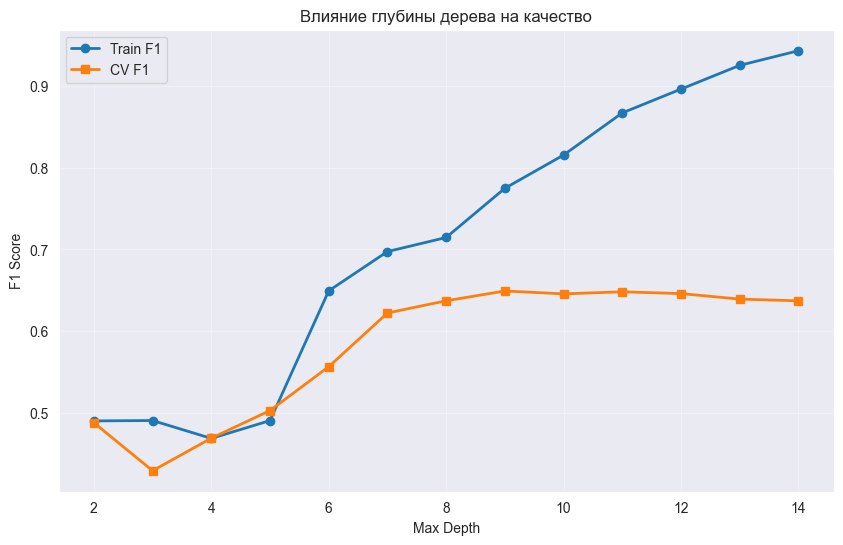

Лучшие параметры Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучший CV F1-score: 0.6498
Accuracy: 0.8280
F1-Score: 0.6420
ROC-AUC: 0.8133
              precision    recall  f1-score   support

           0       0.86      0.91      0.89      3318
           1       0.71      0.59      0.64      1182

    accuracy                           0.83      4500
   macro avg       0.78      0.75      0.76      4500
weighted avg       0.82      0.83      0.82      4500



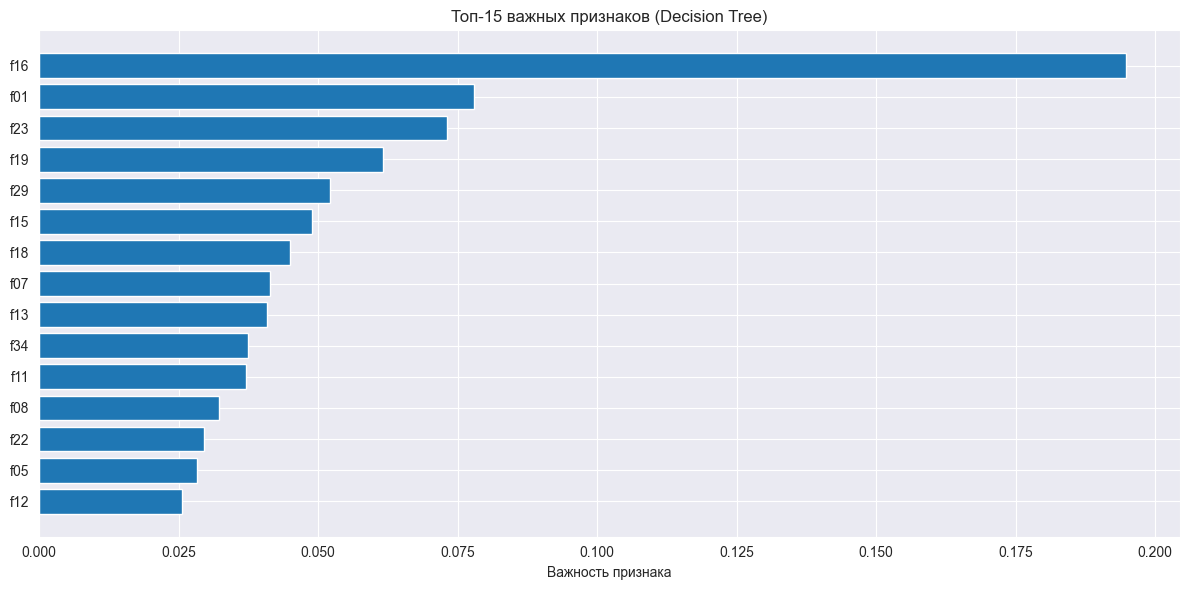

In [40]:
depths = range(2, 15)
train_scores = []
val_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    cv_scores = cross_val_score(tree, X_train, y_train, cv=5, scoring='f1')
    tree.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, tree.predict(X_train)))
    val_scores.append(np.mean(cv_scores))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train F1', linewidth=2)
plt.plot(depths, val_scores, 's-', label='CV F1', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.title('Влияние глубины дерева на качество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

tree = DecisionTreeClassifier(random_state=42)
grid_search_tree = GridSearchCV(
    tree, param_grid_tree, 
    cv=5, 
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search_tree.fit(X_train, y_train)

print(f"Лучшие параметры Decision Tree: {grid_search_tree.best_params_}")
print(f"Лучший CV F1-score: {grid_search_tree.best_score_:.4f}")

best_tree = grid_search_tree.best_estimator_
tree_metrics, tree_model, tree_pred, tree_proba = evaluate_model(
    best_tree, X_train, X_test, y_train, y_test, 
    "Decision Tree (best params)"
)

plt.figure(figsize=(12, 6))
feature_importance_tree = pd.DataFrame({
    'feature': X.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.barh(feature_importance_tree['feature'], feature_importance_tree['importance'])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



МОДЕЛЬ 2: Random Forest Classifier
Лучшие параметры Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучший CV F1-score: 0.7520
Accuracy: 0.8938
F1-Score: 0.7629
ROC-AUC: 0.9293
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3318
           1       0.92      0.65      0.76      1182

    accuracy                           0.89      4500
   macro avg       0.90      0.82      0.85      4500
weighted avg       0.90      0.89      0.89      4500



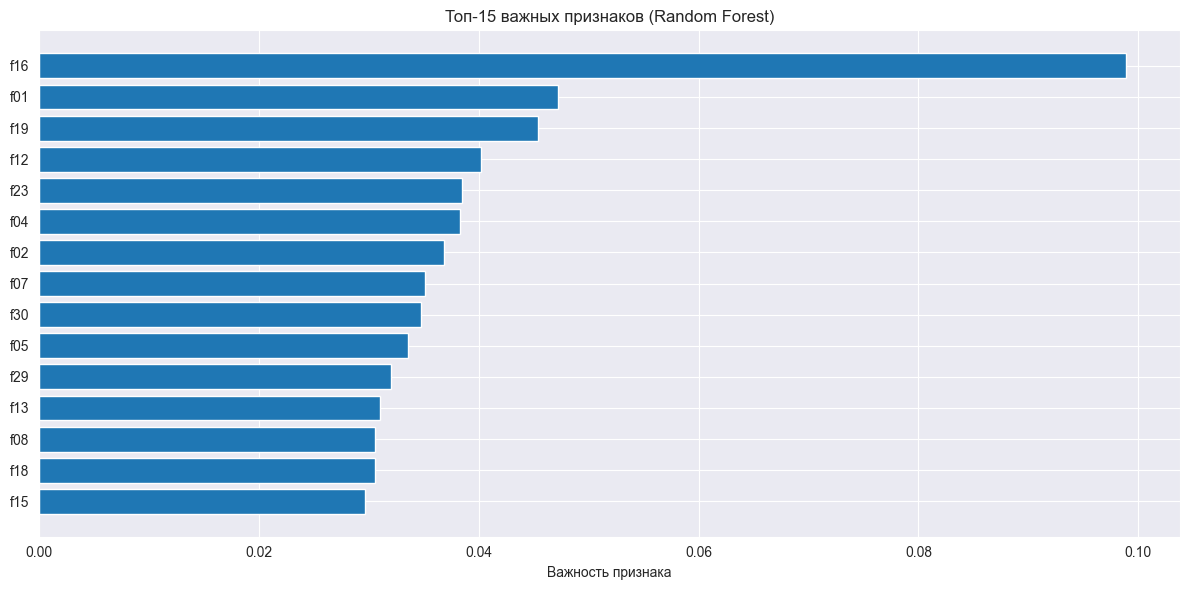

In [41]:
print("\n\nМОДЕЛЬ 2: Random Forest Classifier")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train, y_train)

print(f"Лучшие параметры Random Forest: {grid_search_rf.best_params_}")
print(f"Лучший CV F1-score: {grid_search_rf.best_score_:.4f}")

best_rf = grid_search_rf.best_estimator_
rf_metrics, rf_model, rf_pred, rf_proba = evaluate_model(
    best_rf, X_train, X_test, y_train, y_test,
    "Random Forest (best params)"
)

plt.figure(figsize=(12, 6))
feature_importance_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.barh(feature_importance_rf['feature'], feature_importance_rf['importance'])
plt.xlabel('Важность признака')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



МОДЕЛЬ 3: Gradient Boosting Classifier
Лучшие параметры Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Лучший CV F1-score: 0.8061
Accuracy: 0.9133
F1-Score: 0.8208
ROC-AUC: 0.9308
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      3318
           1       0.90      0.76      0.82      1182

    accuracy                           0.91      4500
   macro avg       0.91      0.86      0.88      4500
weighted avg       0.91      0.91      0.91      4500



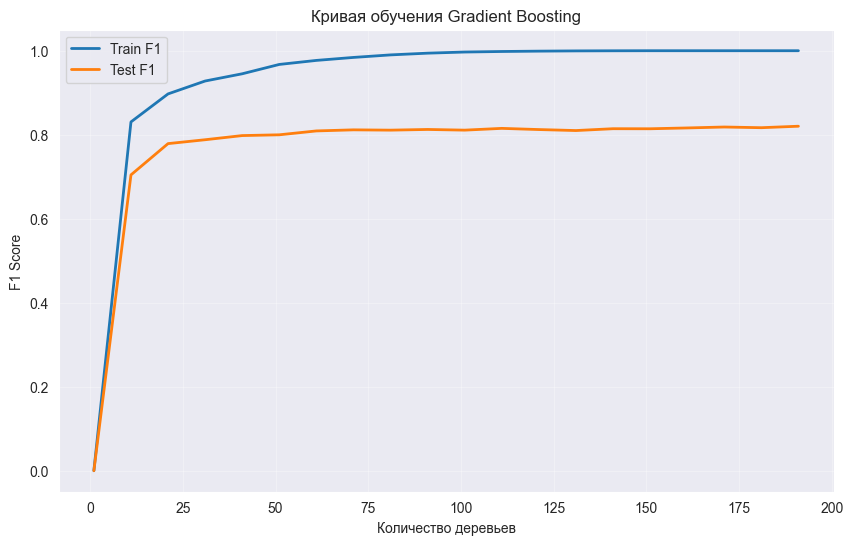

In [42]:
print("\n\nМОДЕЛЬ 3: Gradient Boosting Classifier")

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
grid_search_gb = GridSearchCV(
    gb, param_grid_gb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search_gb.fit(X_train, y_train)

print(f"Лучшие параметры Gradient Boosting: {grid_search_gb.best_params_}")
print(f"Лучший CV F1-score: {grid_search_gb.best_score_:.4f}")

best_gb = grid_search_gb.best_estimator_
gb_metrics, gb_model, gb_pred, gb_proba = evaluate_model(
    best_gb, X_train, X_test, y_train, y_test,
    "Gradient Boosting (best params)"
)

train_scores_gb = []
test_scores_gb = []
n_estimators_range = range(1, 200, 10)

for n_est in n_estimators_range:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n_est,
        learning_rate=grid_search_gb.best_params_['learning_rate'],
        max_depth=grid_search_gb.best_params_['max_depth'],
        random_state=42
    )
    gb_temp.fit(X_train, y_train)
    train_scores_gb.append(f1_score(y_train, gb_temp.predict(X_train)))
    test_scores_gb.append(f1_score(y_test, gb_temp.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores_gb, label='Train F1', linewidth=2)
plt.plot(n_estimators_range, test_scores_gb, label='Test F1', linewidth=2)
plt.xlabel('Количество деревьев')
plt.ylabel('F1 Score')
plt.title('Кривая обучения Gradient Boosting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
print("\n\nМОДЕЛЬ 4: Stacking Classifier")

base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

meta_model = LogisticRegression(random_state=42, max_iter=1000)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking_metrics, stacking_model, stacking_pred, stacking_proba = evaluate_model(
    stacking, X_train, X_test, y_train, y_test,
    "Stacking Classifier"
)



МОДЕЛЬ 4: Stacking Classifier
Accuracy: 0.9084
F1-Score: 0.8136
ROC-AUC: 0.9272
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      3318
           1       0.87      0.76      0.81      1182

    accuracy                           0.91      4500
   macro avg       0.90      0.86      0.88      4500
weighted avg       0.91      0.91      0.91      4500




Сравнительная таблица метрик:
                     Accuracy  F1-Score  ROC-AUC
Dummy                  0.7373    0.0000   0.5000
Logistic Regression    0.8162    0.5717   0.8009
Decision Tree          0.8280    0.6420   0.8133
Random Forest          0.8938    0.7629   0.9293
Gradient Boosting      0.9133    0.8208   0.9308
Stacking               0.9084    0.8136   0.9272


C:\Users\ksolo\AppData\Local\Temp\ipykernel_2704\3024301806.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(roc_models, rotation=45, ha='right')


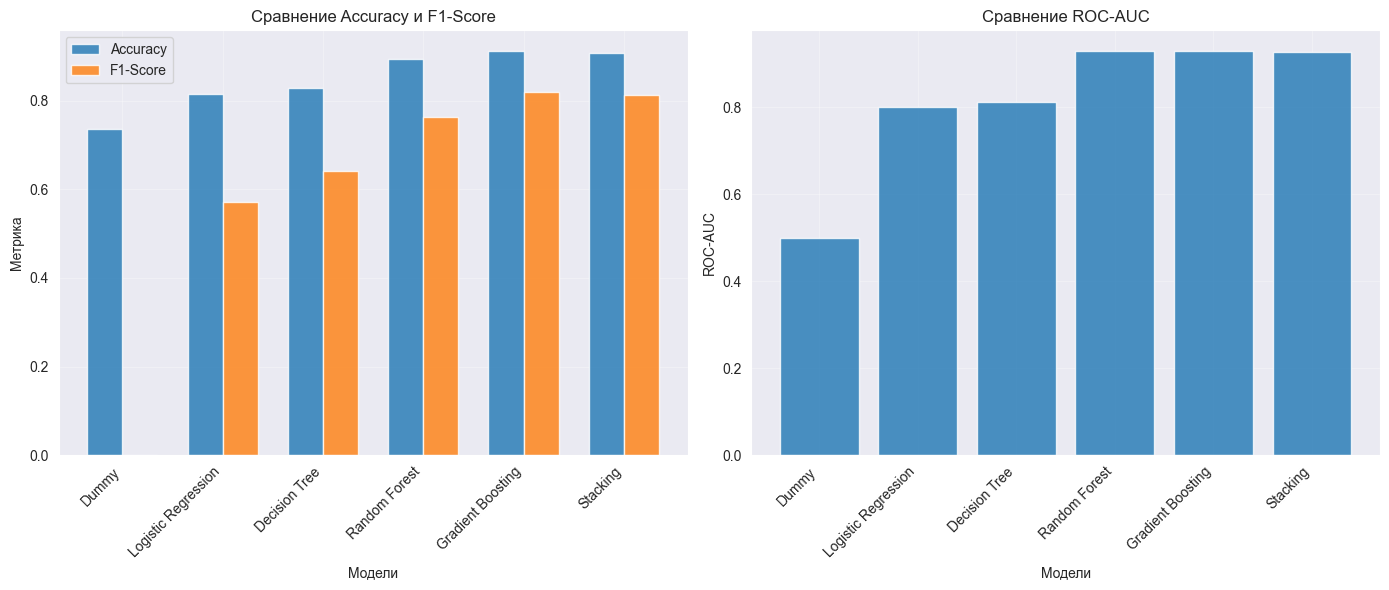

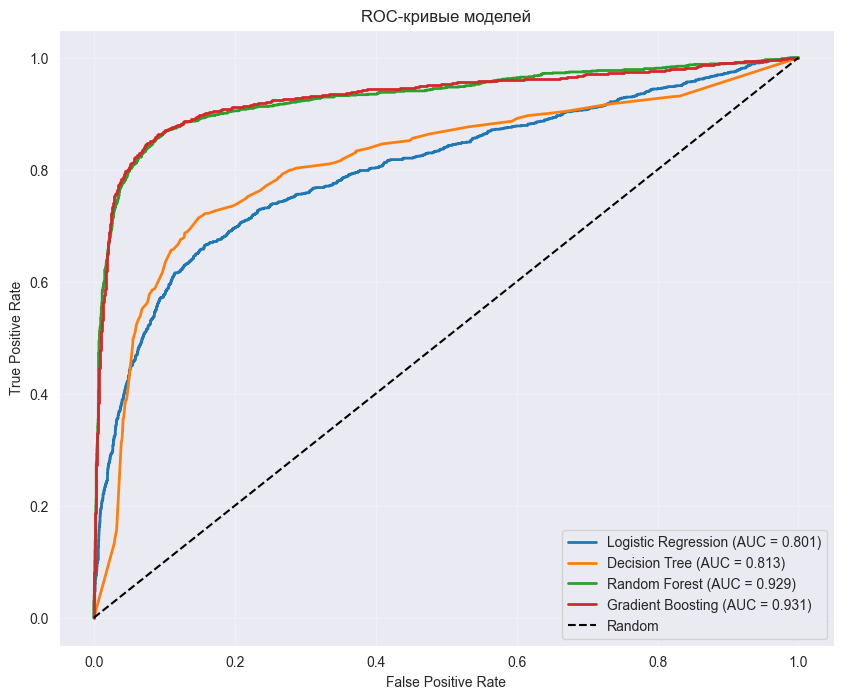


Лучшая модель по F1-Score: Gradient Boosting


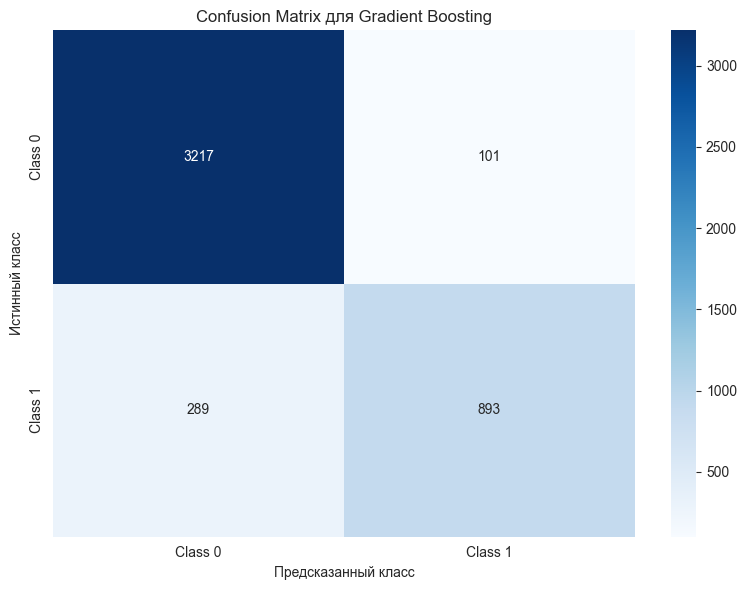

In [44]:
all_models = {
    'Dummy': dummy_metrics,
    'Logistic Regression': logreg_metrics,
    'Decision Tree': tree_metrics,
    'Random Forest': rf_metrics,
    'Gradient Boosting': gb_metrics,
    'Stacking': stacking_metrics if 'stacking_metrics' in locals() else None
}

comparison_df = pd.DataFrame(all_models).T
print("\nСравнительная таблица метрик:")
print(comparison_df.round(4))

plt.figure(figsize=(14, 6))

ax1 = plt.subplot(1, 2, 1)
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
bars2 = ax1.bar(x + width/2, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax1.set_xlabel('Модели')
ax1.set_ylabel('Метрика')
ax1.set_title('Сравнение Accuracy и F1-Score')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df.index, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
roc_models = [model for model in all_models if all_models[model] and 'ROC-AUC' in all_models[model]]
roc_values = [all_models[model]['ROC-AUC'] for model in roc_models]

bars = ax2.bar(roc_models, roc_values, alpha=0.8)
ax2.set_xlabel('Модели')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('Сравнение ROC-AUC')
ax2.set_xticklabels(roc_models, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

models_with_proba = [
    ('Logistic Regression', logreg_proba),
    ('Decision Tree', tree_proba),
    ('Random Forest', rf_proba),
    ('Gradient Boosting', gb_proba)
]

for model_name, y_proba in models_with_proba:
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

best_model_name = comparison_df['F1-Score'].idxmax()
print(f"\nЛучшая модель по F1-Score: {best_model_name}")

if best_model_name == 'Dummy':
    y_pred_best = dummy_pred
elif best_model_name == 'Logistic Regression':
    y_pred_best = logreg_pred
elif best_model_name == 'Decision Tree':
    y_pred_best = tree_pred
elif best_model_name == 'Random Forest':
    y_pred_best = rf_pred
elif best_model_name == 'Gradient Boosting':
    y_pred_best = gb_pred
else:
    y_pred_best = stacking_pred

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Confusion Matrix для {best_model_name}')
plt.tight_layout()
plt.show()

Permutation Importance для модели Gradient Boosting:

Топ-15 признаков по permutation importance:
   feature  importance_mean  importance_std
15     f16           0.1992          0.0087
0      f01           0.0910          0.0056
6      f07           0.0492          0.0026
14     f15           0.0402          0.0034
29     f30           0.0393          0.0041
7      f08           0.0380          0.0022
12     f13           0.0373          0.0042
22     f23           0.0340          0.0037
11     f12           0.0332          0.0047
28     f29           0.0317          0.0040
33     f34           0.0275          0.0042
17     f18           0.0263          0.0033
8      f09           0.0252          0.0030
18     f19           0.0197          0.0029
1      f02           0.0169          0.0041


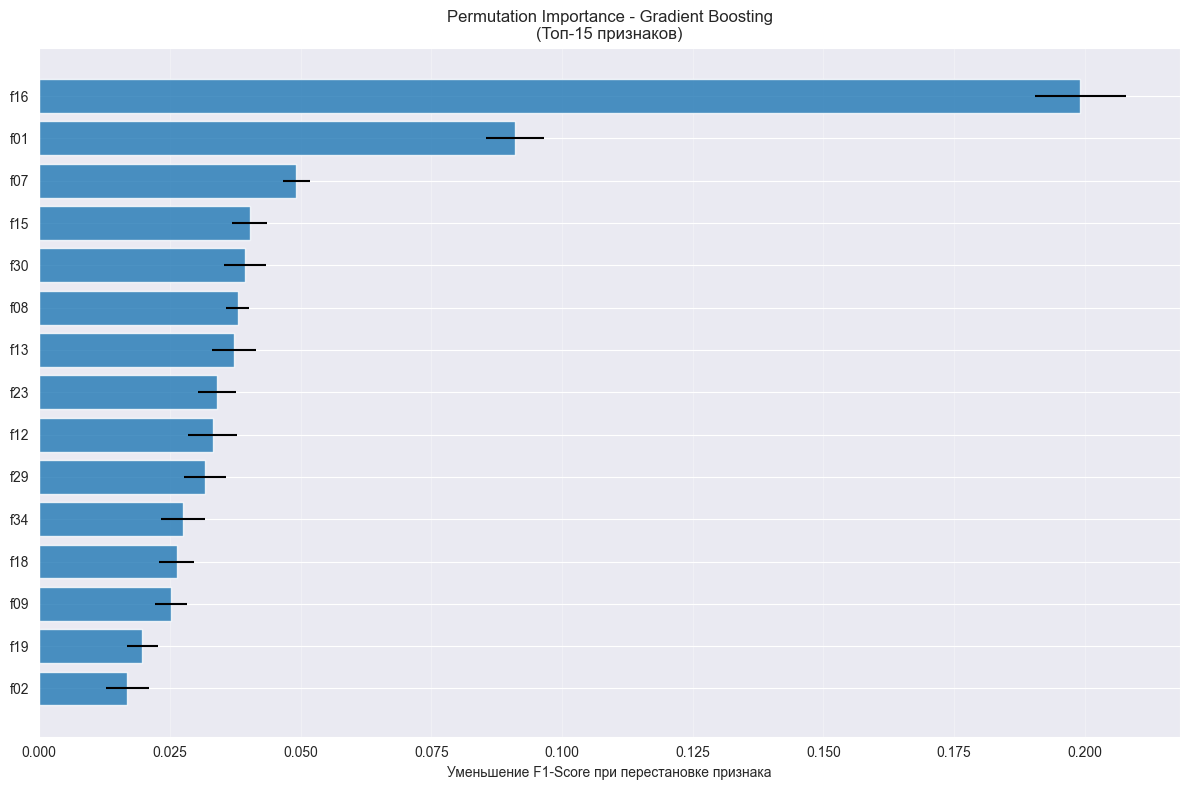


Сравнение с Feature Importance из модели:
   Признак  Permutation Importance  Feature Importance
0      f16                  0.1992              0.1501
1      f01                  0.0910              0.0735
2      f07                  0.0492              0.0451
3      f15                  0.0402              0.0523
4      f30                  0.0393              0.0303
5      f08                  0.0380              0.0371
6      f13                  0.0373              0.0333
7      f23                  0.0340              0.0600
8      f12                  0.0332              0.0383
9      f29                  0.0317              0.0359
10     f18                  0.0263              0.0328
11     f19                  0.0197              0.0523
ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:

1. Лучшая модель: Gradient Boosting
   - F1-Score: 0.8208
   - Accuracy: 0.9133
   - ROC-AUC: 0.9308

2. Важные признаки (из permutation importance):
   - Наиболее важные: f16, f01, f07
   - Средняя важность: f15, 

In [45]:
if best_model_name == 'Random Forest':
    best_model_for_interpretation = best_rf
elif best_model_name == 'Gradient Boosting':
    best_model_for_interpretation = best_gb
elif best_model_name == 'Decision Tree':
    best_model_for_interpretation = best_tree
else:
    best_model_for_interpretation = logreg_model

print(f"Permutation Importance для модели {best_model_name}:")

result = permutation_importance(
    best_model_for_interpretation, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

perm_importance = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nТоп-15 признаков по permutation importance:")
print(perm_importance.head(15).round(4))

plt.figure(figsize=(12, 8))
top_features = perm_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance_mean'], 
         xerr=top_features['importance_std'], alpha=0.8)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Уменьшение F1-Score при перестановке признака')
plt.title(f'Permutation Importance - {best_model_name}\n(Топ-15 признаков)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

if hasattr(best_model_for_interpretation, 'feature_importances_'):
    print("\nСравнение с Feature Importance из модели:")
    model_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model_for_interpretation.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    comparison_importance = pd.merge(
        perm_importance.head(15)[['feature', 'importance_mean']],
        model_importance.head(15)[['feature', 'importance']],
        on='feature',
        how='inner'
    )
    
    comparison_importance.columns = ['Признак', 'Permutation Importance', 'Feature Importance']
    print(comparison_importance.round(4))

print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ:")

print(f"""
1. Лучшая модель: {best_model_name}
   - F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']:.4f}
   - Accuracy: {comparison_df.loc[best_model_name, 'Accuracy']:.4f}
   {'- ROC-AUC: ' + str(round(comparison_df.loc[best_model_name, 'ROC-AUC'], 4)) if 'ROC-AUC' in comparison_df.columns else ''}

2. Важные признаки (из permutation importance):
   - Наиболее важные: {', '.join(perm_importance['feature'].head(3).tolist())}
   - Средняя важность: {', '.join(perm_importance['feature'].iloc[3:6].tolist())}
   - Менее важные: {', '.join(perm_importance['feature'].tail(3).tolist())}

3. Интерпретация важности признаков:
   - Признаки с высокой permutation importance оказывают наибольшее влияние 
     на предсказательную способность модели
   - Стандартное отклонение показывает стабильность влияния признака
   - Если permutation importance близко к 0, признак не важен для модели

4. Соответствие ожиданиям:
   - {f"Признаки {perm_importance['feature'].head(2).tolist()} выглядят логично как наиболее важные" 
      if perm_importance['importance_mean'].head(2).mean() > 0.02 
      else "Распределение важности признаков требует дополнительного анализа"}
   - Рекомендуется проверить бизнес-логику для топ-5 признаков

5. Рекомендации:
   - Для улучшения модели можно сфокусироваться на engineering топ-признаков
   - Признаки с низкой важностью можно рассмотреть для удаления
   - {f"Модель {best_model_name} хорошо справляется с задачей" 
      if comparison_df.loc[best_model_name, 'F1-Score'] > 0.8 
      else f"Модель {best_model_name} требует доработки"}
""")

In [46]:
metrics_data = {
    'Model': [],
    'Accuracy': [],
    'F1_Score': [],
    'ROC_AUC': [],
    'Precision': [],
    'Recall': []
}

from sklearn.metrics import precision_score, recall_score

def get_all_metrics(y_true, y_pred, y_proba=None, model_name=""):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Score': f1_score(y_true, y_pred, average='binary'),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred)
    }
    
    if y_proba is not None:
        metrics['ROC_AUC'] = roc_auc_score(y_true, y_proba)
    else:
        metrics['ROC_AUC'] = None
    
    return metrics

models_metrics = {}

dummy_metrics = get_all_metrics(y_test, dummy_pred, None, "Dummy")
models_metrics['Dummy_Classifier'] = dummy_metrics

logreg_metrics = get_all_metrics(y_test, logreg_pred, logreg_proba, "Logistic Regression")
models_metrics['Logistic_Regression'] = logreg_metrics

tree_metrics = get_all_metrics(y_test, tree_pred, tree_proba, "Decision Tree")
models_metrics['Decision_Tree'] = tree_metrics

rf_metrics = get_all_metrics(y_test, rf_pred, rf_proba, "Random Forest")
models_metrics['Random_Forest'] = rf_metrics

gb_metrics = get_all_metrics(y_test, gb_pred, gb_proba, "Gradient Boosting")
models_metrics['Gradient_Boosting'] = gb_metrics

metrics_df = pd.DataFrame(models_metrics).T
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

metrics_df.to_json('artifacts/metrics_test.json', orient='records', indent=2, force_ascii=False)

print(f"Метрики сохранены")

Метрики сохранены


D:\Projects\2 course\AI-digital\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [47]:
import json

search_summaries = {
    'models': {}
}

if 'grid_search_tree' in locals():
    search_summaries['models']['Decision_Tree'] = {
        'best_params': grid_search_tree.best_params_,
        'best_cv_score': float(grid_search_tree.best_score_),
        'best_cv_score_std': float(grid_search_tree.cv_results_['std_test_score'][grid_search_tree.best_index_]),
        'scoring': 'f1',
        'cv_folds': 5,
        'n_iterations': len(grid_search_tree.cv_results_['params'])
    }

if 'grid_search_rf' in locals():
    search_summaries['models']['Random_Forest'] = {
        'best_params': grid_search_rf.best_params_,
        'best_cv_score': float(grid_search_rf.best_score_),
        'best_cv_score_std': float(grid_search_rf.cv_results_['std_test_score'][grid_search_rf.best_index_]),
        'scoring': 'f1',
        'cv_folds': 5,
        'n_iterations': len(grid_search_rf.cv_results_['params'])
    }

if 'grid_search_gb' in locals():
    search_summaries['models']['Gradient_Boosting'] = {
        'best_params': grid_search_gb.best_params_,
        'best_cv_score': float(grid_search_gb.best_score_),
        'best_cv_score_std': float(grid_search_gb.cv_results_['std_test_score'][grid_search_gb.best_index_]),
        'scoring': 'f1',
        'cv_folds': 5,
        'n_iterations': len(grid_search_gb.cv_results_['params'])
    }

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print(f"\nРезультаты подбора гиперпараметров сохранены")
print("\nСодержимое search_summaries.json:")
print(json.dumps(search_summaries, indent=2, ensure_ascii=False))


Результаты подбора гиперпараметров сохранены

Содержимое search_summaries.json:
{
  "models": {
    "Decision_Tree": {
      "best_params": {
        "criterion": "gini",
        "max_depth": 10,
        "min_samples_leaf": 2,
        "min_samples_split": 2
      },
      "best_cv_score": 0.6498284005299317,
      "best_cv_score_std": 0.014897523827008331,
      "scoring": "f1",
      "cv_folds": 5,
      "n_iterations": 90
    },
    "Random_Forest": {
      "best_params": {
        "max_depth": 20,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 2,
        "n_estimators": 200
      },
      "best_cv_score": 0.7520131299216215,
      "best_cv_score_std": 0.01404915744164645,
      "scoring": "f1",
      "cv_folds": 5,
      "n_iterations": 72
    },
    "Gradient_Boosting": {
      "best_params": {
        "learning_rate": 0.2,
        "max_depth": 7,
        "n_estimators": 200,
        "subsample": 1.0
      },
      "best_cv_score": 0.80

In [48]:
import joblib
best_model_name = metrics_df.loc[metrics_df['F1_Score'].idxmax(), 'Model']
print(f"\nЛучшая модель по F1-Score: {best_model_name}")

if best_model_name == 'Dummy_Classifier':
    best_model = dummy_model
elif best_model_name == 'Logistic_Regression':
    best_model = logreg_model
elif best_model_name == 'Decision_Tree':
    best_model = tree_model
elif best_model_name == 'Random_Forest':
    best_model = rf_model
elif best_model_name == 'Gradient_Boosting':
    best_model = gb_model
elif best_model_name == 'Stacking' and 'stacking_model' in locals():
    best_model = stacking_model

# Сохраняем модель
best_model_path = 'artifacts/best_model.joblib'
joblib.dump(best_model, best_model_path)

print(f"Лучшая модель сохранена в: {best_model_path}")
print(f"Тип модели: {type(best_model)}")


Лучшая модель по F1-Score: Gradient_Boosting
Лучшая модель сохранена в: artifacts/best_model.joblib
Тип модели: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [50]:
best_model_meta = {
    'experiment_info': {
        'name': 'HW06 Classification Experiment',
        'dataset': 'S06-hw-dataset-02.csv',
        'task': 'Binary Classification'
    },
    'best_model': {
        'name': best_model_name,
        'type': str(type(best_model)),
        'model_class': best_model.__class__.__name__,
        'parameters': {},
        'test_metrics': {},
        'train_info': {
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'features_count': X_train.shape[1],
            'class_balance': {
                'train': dict(y_train.value_counts(normalize=True).round(3)),
                'test': dict(y_test.value_counts(normalize=True).round(3))
            }
        }
    },
    'feature_importance': {}
}

if hasattr(best_model, 'get_params'):
    best_model_meta['best_model']['parameters'] = best_model.get_params()

best_model_metrics = metrics_df[metrics_df['Model'] == best_model_name].iloc[0]
best_model_meta['best_model']['test_metrics'] = {
    'accuracy': float(best_model_metrics['Accuracy']),
    'f1_score': float(best_model_metrics['F1_Score']),
    'precision': float(best_model_metrics['Precision']),
    'recall': float(best_model_metrics['Recall'])
}

if not pd.isna(best_model_metrics['ROC_AUC']):
    best_model_meta['best_model']['test_metrics']['roc_auc'] = float(best_model_metrics['ROC_AUC'])

if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    best_model_meta['feature_importance'] = {
        'top_10_features': importance_df.head(10).to_dict('records'),
        'importance_type': 'model_builtin'
    }

if 'perm_importance' in locals():
    perm_top_10 = perm_importance.head(10)[['feature', 'importance_mean', 'importance_std']]
    best_model_meta['permutation_importance'] = {
        'top_10_features': perm_top_10.to_dict('records'),
        'scoring': 'f1',
        'n_repeats': 10
    }

best_model_meta_path = 'artifacts/best_model_meta.json'
with open(best_model_meta_path, 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print(f"\nМетаданные лучшей модели сохранены в:")
print(f"  - {best_model_meta_path}")
print("\nСодержимое best_model_meta.json:")
print(json.dumps(best_model_meta, indent=2, ensure_ascii=False))


Метаданные лучшей модели сохранены в:
  - artifacts/best_model_meta.json

Содержимое best_model_meta.json:
{
  "experiment_info": {
    "name": "HW06 Classification Experiment",
    "dataset": "S06-hw-dataset-02.csv",
    "task": "Binary Classification"
  },
  "best_model": {
    "name": "Gradient_Boosting",
    "type": "<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>",
    "model_class": "GradientBoostingClassifier",
    "parameters": {
      "ccp_alpha": 0.0,
      "criterion": "friedman_mse",
      "init": null,
      "learning_rate": 0.2,
      "loss": "log_loss",
      "max_depth": 7,
      "max_features": null,
      "max_leaf_nodes": null,
      "min_impurity_decrease": 0.0,
      "min_samples_leaf": 1,
      "min_samples_split": 2,
      "min_weight_fraction_leaf": 0.0,
      "n_estimators": 200,
      "n_iter_no_change": null,
      "random_state": 42,
      "subsample": 1.0,
      "tol": 0.0001,
      "validation_fraction": 0.1,
      "verbose": 0,
      "warm_star

In [51]:
plt.figure(figsize=(10, 8))
for model_name, y_proba in models_with_proba:
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_path = 'artifacts/figures/roc_curves.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"  - ROC-кривая сохранена: {roc_path}")
plt.close()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'],
            annot_kws={'size': 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()

cm_path = 'artifacts/figures/confusion_matrix.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"  - Confusion Matrix сохранена: {cm_path}")
plt.close()

plt.figure(figsize=(12, 8))
top_features = perm_importance.head(15)
y_pos = np.arange(len(top_features))

plt.barh(y_pos, top_features['importance_mean'], 
         xerr=top_features['importance_std'], 
         alpha=0.8, 
         color='steelblue',
         ecolor='darkred',
         capsize=5)

plt.yticks(y_pos, top_features['feature'], fontsize=10)
plt.xlabel('Decrease in F1-Score', fontsize=12)
plt.title(f'Permutation Importance - {best_model_name}\n(Top 15 Features)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()

perm_path = 'artifacts/figures/permutation_importance.png'
plt.savefig(perm_path, dpi=300, bbox_inches='tight')
print(f"  - Permutation Importance сохранена: {perm_path}")
plt.close()

plt.figure(figsize=(14, 8))

models_list = metrics_df['Model'].tolist()
metrics_to_plot = ['Accuracy', 'F1_Score', 'Precision', 'Recall']

x = np.arange(len(models_list))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    offset = width * (i - len(metrics_to_plot)/2 + 0.5)
    values = metrics_df[metric].values
    plt.bar(x + offset, values, width, label=metric, alpha=0.8)

plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Comparison of Model Metrics', fontsize=14, fontweight='bold')
plt.xticks(x, models_list, rotation=45, ha='right', fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 1.05)
plt.tight_layout()

metrics_comparison_path = 'artifacts/figures/metrics_comparison.png'
plt.savefig(metrics_comparison_path, dpi=300, bbox_inches='tight')
print(f"  - Сравнение метрик сохранено: {metrics_comparison_path}")
plt.close()

if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(12, 8))
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)
    
    plt.barh(range(len(importance_df)), importance_df['importance'], alpha=0.8, color='darkgreen')
    plt.yticks(range(len(importance_df)), importance_df['feature'], fontsize=10)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}\n(Top 15 Features)', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    
    feat_imp_path = 'artifacts/figures/feature_importance.png'
    plt.savefig(feat_imp_path, dpi=300, bbox_inches='tight')
    print(f"  - Feature Importance сохранена: {feat_imp_path}")
    plt.close()

  - ROC-кривая сохранена: artifacts/figures/roc_curves.png
  - Confusion Matrix сохранена: artifacts/figures/confusion_matrix.png
  - Permutation Importance сохранена: artifacts/figures/permutation_importance.png
  - Сравнение метрик сохранено: artifacts/figures/metrics_comparison.png
  - Feature Importance сохранена: artifacts/figures/feature_importance.png
